In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [2]:
width = 1500
height = 1500
cutout_left = 1000
cutout_top = 500

vertices = [
    (0, height),
    (width, height),
    (width, cutout_top),
    (cutout_left, cutout_top),
    (cutout_left, 0),
    (0, 0)
]

edges = [
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 0]
]


In [3]:
# map x and map y are the map coordinates.
# A map is a view projected over a real world area. 
# The 0, 0 world x, y could be anywhere within the map.
# Remember that the edges are all defined in world coordinates.

margin = 100

wx_range = np.arange(-margin, width + margin)
wy_range = np.arange(-margin, height + margin)
map_to_world = np.meshgrid(wx_range, wy_range, indexing='xy')

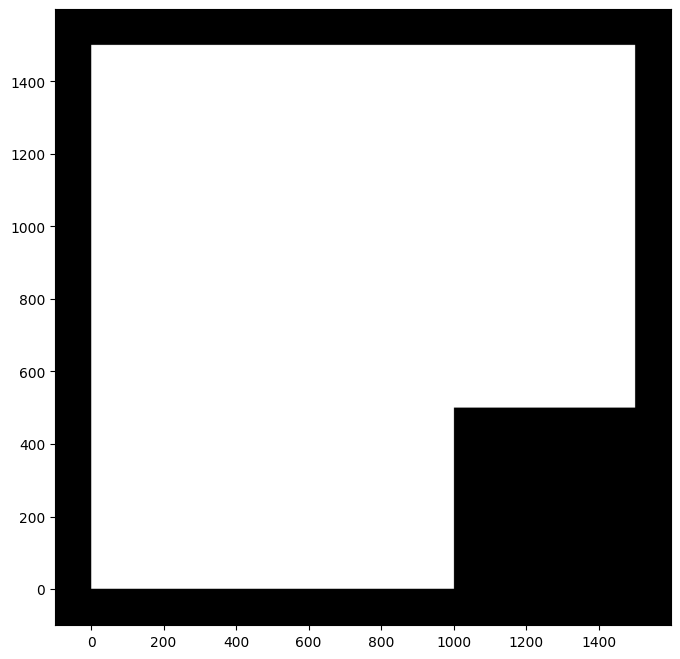

In [6]:
inside_boundary_field = np.zeros_like(map_to_world[0], dtype=np.float32)

wx, wy = map_to_world
main_mask = (wx >= 0) & (wx <= width) & (wy >= 0) & (wy <= height)
cutout_mask = (wx > cutout_left) & (wy < cutout_top)
inside_mask = main_mask & (~cutout_mask)
inside_boundary_field[inside_mask] = 1

# Draw it
plt.figure(figsize=(8, 8))
plt.gca().set_facecolor('black')

plt.xlim(wx_range[0], wx_range[-1])
plt.ylim(wy_range[0], wy_range[-1])

plt.imshow(
    inside_boundary_field,
    cmap='gray',
    origin='lower',
    extent=[wx_range[0], wx_range[-1], wy_range[0], wy_range[-1]]
)

In [14]:
print("World (-10, -10) = ", inside_boundary_field[margin - 10, margin - 10])
print("World (0, 0) = ", inside_boundary_field[margin, margin])
print("World (10, 10) = ", inside_boundary_field[margin + 10, margin + 10])

World (-10, -10) =  0.0
World (0, 0) =  1.0
World (10, 10) =  1.0


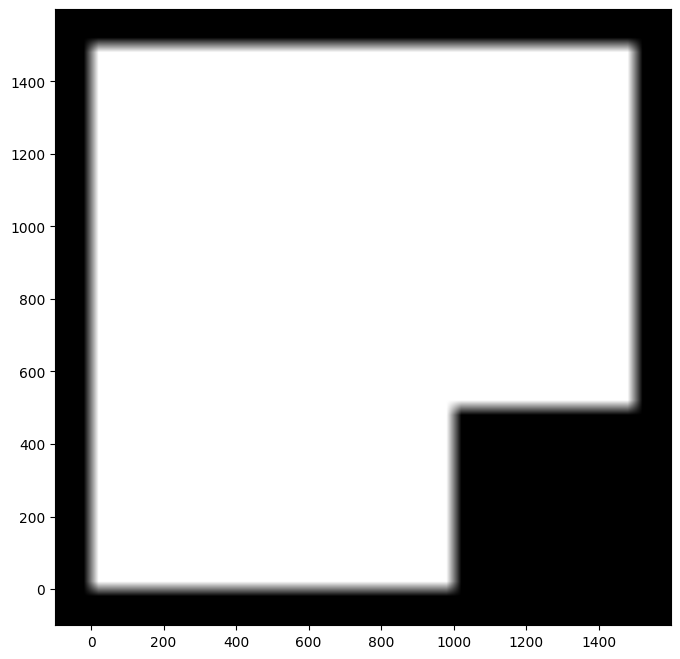

In [11]:
span = 41
blurred = cv2.blur(inside_boundary_field, (span, span))

plt.figure(figsize=(8, 8))
plt.gca().set_facecolor('black')

plt.xlim(wx_range[0], wx_range[-1])
plt.ylim(wy_range[0], wy_range[-1])

plt.imshow(
    blurred,
    cmap='gray',
    origin='lower',
    extent=[wx_range[0], wx_range[-1], wy_range[0], wy_range[-1]]
)

In [15]:
print("World (-10, -10) = ", blurred[margin - 10, margin - 10])
print("World (0, 0) = ", blurred[margin, margin])
print("World (10, 10) = ", blurred[margin + 10, margin + 10])

World (-10, -10) =  0.07198096
World (0, 0) =  0.26234385
World (10, 10) =  0.5716835


In [16]:
print("World (-41, -41) = ", blurred[margin - 41, margin - 41])
print("World (0, 0) = ", blurred[margin, margin])
print("World (41, 41) = ", blurred[margin + 41, margin + 41])

World (-41, -41) =  0.0
World (0, 0) =  0.26234385
World (41, 41) =  1.0


In [18]:
np.save('../robot/boundary_probabilities.npy', blurred)